In [1]:
import numpy as np
import cvxpy as cp
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [2]:
# data reading
soft08_data = pd.read_csv(f"numerical results/UK08ww1.csv")
soft10_data = pd.read_csv(f"numerical results/UK10ww1.csv")
soft12_data = pd.read_csv(f"numerical results/UK12ww1.csv")
soft15_data = pd.read_csv(f"numerical results/UK15ww1.csv")
hard08_data = pd.read_csv(f"numerical results/UK08hard.csv")
hard10_data = pd.read_csv(f"numerical results/UK10hard.csv")
hard12_data = pd.read_csv(f"numerical results/UK12hard.csv")
hard15_data = pd.read_csv(f"numerical results/UK15hard.csv")

# soft10_data processing
soft10_data = soft10_data[soft10_data['method'] == 'soft WDRMPC'].copy()
# soft10_data

# total05_data processing
total05_data = pd.read_csv(f"Numerical results/UK05hard.csv")
soft05_data = total05_data[total05_data['method'] == 'soft WDRMPC'].copy()
hard05_data = total05_data[total05_data['method'] == 'hard WDRMPC'].copy()

In [3]:
soft_fea_05 = len(soft05_data) / 30 * 100
soft_fea_08 = len(soft08_data) / 30 * 100
soft_fea_10 = len(soft10_data) / 30 * 100
soft_fea_12 = len(soft12_data) / 30 * 100
soft_fea_15 = len(soft15_data) / 30 * 100
soft_feasibility = [soft_fea_05, soft_fea_08, soft_fea_10, soft_fea_12, soft_fea_15]

hard_fea_05 = len(hard05_data) / 30 * 100
hard_fea_08 = len(hard08_data) / 30 * 100
hard_fea_10 = len(hard10_data) / 30 * 100
hard_fea_12 = len(hard12_data) / 30 * 100
hard_fea_15 = len(hard15_data) / 30 * 100
hard_feasibility = [hard_fea_05, hard_fea_08, hard_fea_10, hard_fea_12, hard_fea_15]

print(soft_feasibility)
print(hard_feasibility)

[100.0, 100.0, 100.0, 96.66666666666667, 90.0]
[100.0, 90.0, 80.0, 23.333333333333332, 6.666666666666667]


In [4]:
hard05_ids = hard05_data['id']
mask = soft05_data['id'].isin(hard05_ids)
filtered_soft05_data = soft05_data[mask]
soft05_mean = filtered_soft05_data['cost'].mean()
hard05_mean = hard05_data['cost'].mean()

hard08_ids = hard08_data['id']
mask = soft08_data['id'].isin(hard08_ids)
filtered_soft08_data = soft08_data[mask]
soft08_mean = filtered_soft08_data['cost'].mean()
hard08_mean = hard08_data['cost'].mean()

hard10_ids = hard10_data['id']
mask = soft10_data['id'].isin(hard10_ids)
filtered_soft10_data = soft10_data[mask]
soft10_mean = filtered_soft10_data['cost'].mean()
hard10_mean = hard10_data['cost'].mean()

hard12_ids = hard12_data['id']
mask = soft12_data['id'].isin(hard12_ids)
filtered_soft12_data = soft12_data[mask]
soft12_mean = filtered_soft12_data['cost'].mean()
hard12_mean = hard12_data['cost'].mean()

hard15_ids = hard15_data['id']
mask = soft15_data['id'].isin(hard15_ids)
filtered_soft15_data = soft15_data[mask]
soft15_mean = filtered_soft15_data['cost'].mean()
hard15_mean = hard15_data['cost'].mean()

soft_costs = [soft05_mean, soft08_mean, soft10_mean, soft12_mean, soft15_mean]
hard_costs = [soft05_mean, hard08_mean, hard10_mean, hard12_mean, hard15_mean]

print(soft_costs)
print(hard_costs)

[np.float64(875.204836274768), np.float64(939.6314286539421), np.float64(997.9332884722603), np.float64(1026.746033770098), np.float64(1217.8403412152363)]
[np.float64(875.204836274768), np.float64(942.2566683935562), np.float64(997.9647117504693), np.float64(1026.290010416503), np.float64(1213.63700301782)]


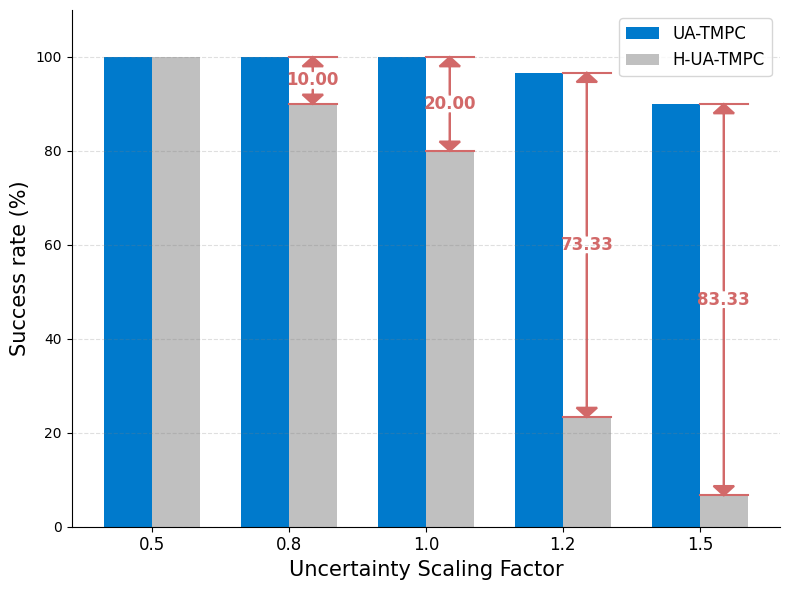

In [5]:
from matplotlib.patches import FancyArrowPatch # 导入我们需要的工具
# scenarios = [r"0.8$\times$", r"1.0$\times$", r"1.2$\times$", r"1.5$\times$"]
scenarios = [r"0.5", r"0.8", r"1.0", r"1.2", r"1.5"]
# --- 2. 绘图设置 ---
x = np.arange(len(scenarios))  # X轴的位置
width = 0.35  # 条形的宽度

# 创建画布和坐标轴
fig, ax = plt.subplots(figsize=(8, 6))

# 定义颜色 (突出色 vs 中性色)
color_method_A = '#007ACC' # 醒目的蓝色
color_method_B = '#C0C0C0' # 柔和的灰色

# 绘制条形图
bars1 = ax.bar(x - width/2, soft_feasibility, width, label='UA-TMPC', color=color_method_A)
bars2 = ax.bar(x + width/2, hard_feasibility, width, label='H-UA-TMPC', color=color_method_B)

# --- 3. 添加数据标签 (核心部分) ---
# 封装一个函数来添加标签，更整洁
def add_labels(bars, costs):
    for i, bar in enumerate(bars):
        height = bar.get_height()
        # 可行率标签
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, weight='bold')
        # 成本标签
        ax.annotate(f'Cost: \n {costs[i]:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height / 2), # 放在条形中间
                    ha='center', va='center', fontsize=9, color='white', weight='bold')

# add_labels(bars1, soft_costs)
# add_labels(bars2, hard_costs)

# --- 4. 美化图表 ---
ax.set_ylabel('Success rate (%)', fontsize=15)
# ax.set_title('方法A vs 方法B 在四种场景下的性能对比', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(scenarios, fontsize=12)
ax.set_xlabel('Uncertainty Scaling Factor', fontsize=15)
ax.legend(fontsize=12)

# Y轴范围设置得更高一些，给标签留出空间
ax.set_ylim(0, max(soft_feasibility) * 1.1)

# 去除顶部和右侧的边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加柔和的水平网格线
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.25)

labels = scenarios
s_dr_tmpc_rates = soft_feasibility
h_dr_tmpc_rates = hard_feasibility

# 3. 添加箭头指向外部的“工字型”标注
# ===================================================
for i in range(len(labels)):
    height_blue = s_dr_tmpc_rates[i]
    height_gray = h_dr_tmpc_rates[i]
    difference = height_blue - height_gray

    if difference > 1:
        # --- 核心修改：组合所有最佳实践 ---
        
        # 1. 定义标注颜色 (更专业的深红色)
        # annotation_color = '#B22222'  # 'Firebrick' color
        # annotation_color = 'indianred'
        annotation_color = '#D26969'
        # annotation_color = 'green'

        # 2. 计算几何位置
        x_gray_center = x[i] + width / 2  # 灰色柱子的中心 x 坐标
        
        # 横线的左右边界，与灰色柱子对齐
        cap_x_left = x_gray_center - width / 2
        cap_x_right = x_gray_center + width / 2

        # 计算间隙的中心和边界
        mid_point_y = (height_blue + height_gray) / 2
        text_vertical_padding = 2.0  # 控制数字上下的留白
        gap_top = mid_point_y + text_vertical_padding
        gap_bottom = mid_point_y - text_vertical_padding

        # 3. 绘制与灰色柱子等宽的水平线
        ax.plot([cap_x_left, cap_x_right], [height_blue, height_blue],
                color=annotation_color, linewidth=1.5)
        ax.plot([cap_x_left, cap_x_right], [height_gray, height_gray],
                color=annotation_color, linewidth=1.5)

        # 4. 绘制两个朝外的箭头
        head_width = 0.15 
        head_length = 2.0
        
        # 向上箭头: 从间隙上边界指向顶部横线
        ax.arrow(
            x=x_gray_center, y=gap_top,
            dx=0, dy=height_blue - gap_top - head_length,
            head_width=head_width, head_length=head_length,
            fc=annotation_color, ec=annotation_color, lw=1.5,
        )
        # 向下箭头: 从间隙下边界指向底部横线
        ax.arrow(
            x=x_gray_center, y=gap_bottom+head_length - head_length,
            dx=0, dy=height_gray - gap_bottom + head_length,
            head_width=head_width, head_length=head_length,
            fc=annotation_color, ec=annotation_color, lw=1.5,
        )

        # 5. 将文本放置在间隙中心
        ax.text(
            x_gray_center,
            mid_point_y,
            f'{difference:.2f}',
            ha='center', va='center',
            color=annotation_color, fontsize=12, weight='bold'
        )

fig.tight_layout() # 调整布局
plt.savefig(f"figures/scenario.pdf", bbox_inches='tight')
plt.show()